In [19]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [20]:
df.dropna(inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


In [21]:
numeric_columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

df[numeric_columns].describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000


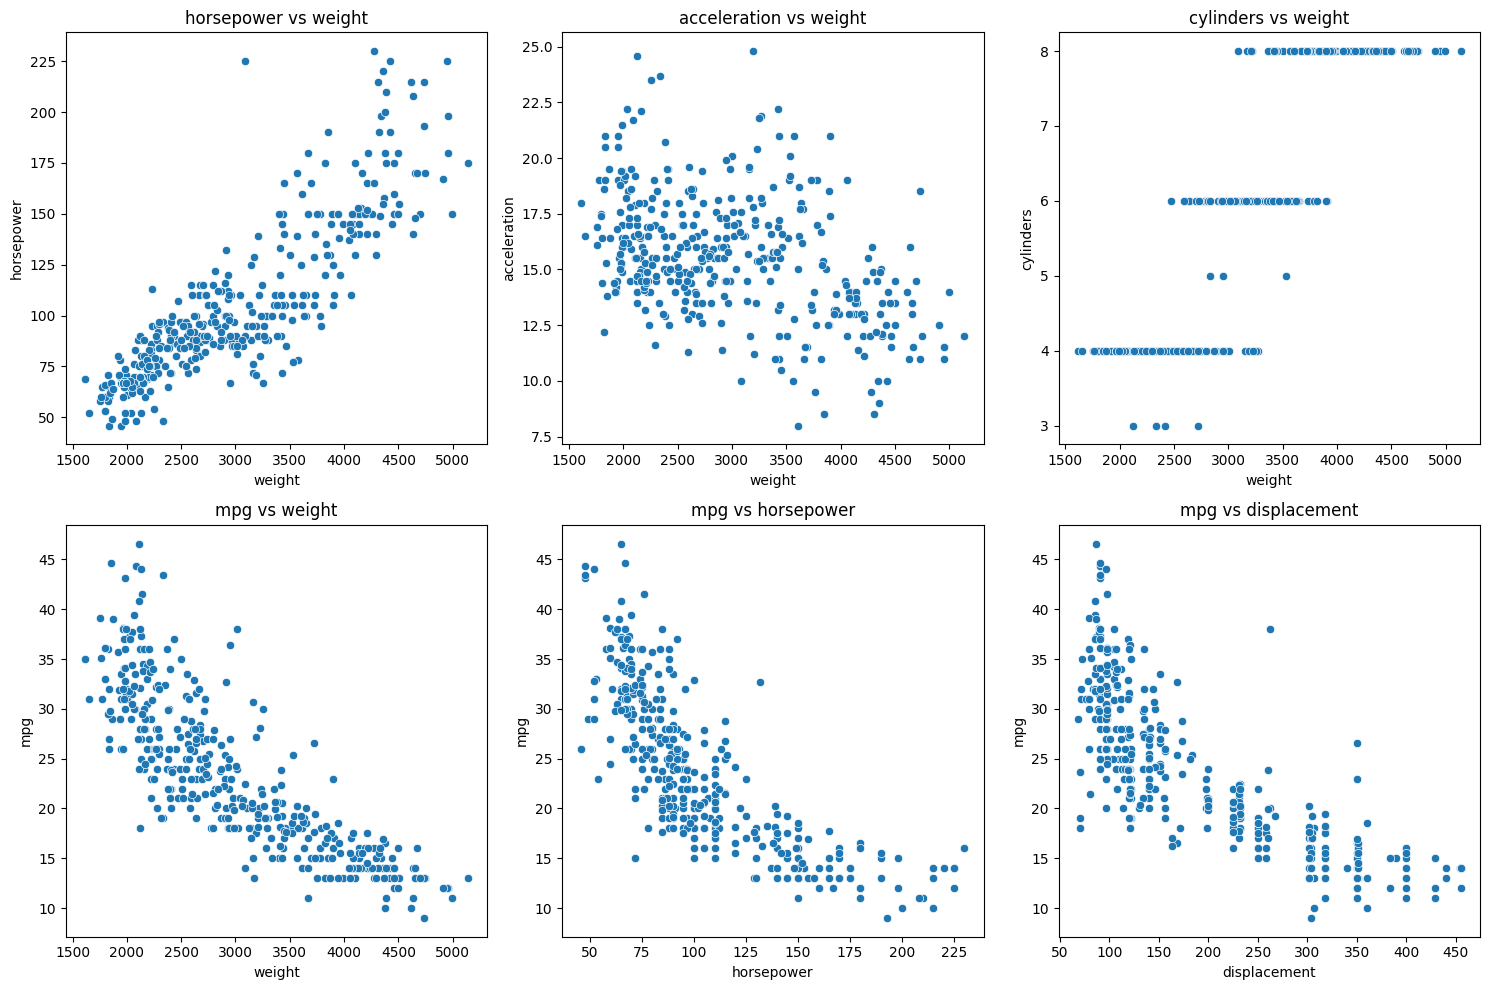

In [22]:
plot_pairs = [
    ('weight', 'horsepower'), ('weight', 'acceleration'), ('weight', 'cylinders'),
    ('weight', 'mpg'), ('horsepower', 'mpg'), ('displacement', 'mpg')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (x_col, y_col) in enumerate(plot_pairs):
    row = i // 3
    col = i % 3

    sns.scatterplot(data=df, x=x_col, y=y_col, ax=axes[row, col])
    axes[row, col].set_title(f'{y_col} vs {x_col}')

plt.tight_layout()
plt.show()

In [23]:
df_cleaned = df.drop(columns=['name', 'origin'])

df_cleaned.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [24]:
from sklearn.model_selection import train_test_split

y = df_cleaned['mpg']
X = df_cleaned.drop(columns='mpg')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (313, 6)
X_test shape: (79, 6)
y_train shape: (313,)
y_test shape: (79,)


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import numpy as np

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_regression(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    print(f'MAE: {mae:.2f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')

model_ols = LinearRegression()
evaluate_regression(X_train_scaled, X_test_scaled, y_train, y_test, model_ols)



MAE: 2.50
MSE: 10.50
RMSE: 3.24


In [26]:
def get_matrics(X_test, y_test, model):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    return mae, mse, rmse



In [28]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

results = {}

model_svd = LinearRegression().fit(X_train, y_train)
results['Linear regr. SVD'] = get_matrics(X_test, y_test, model_svd)

model_svd_scaled = LinearRegression().fit(X_train_scaled, y_train)
results['Linear regr. SVD scaled'] = get_matrics(X_test_scaled, y_test, model_svd_scaled)

degrees = [1, 2, 3]

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    model_poly = LinearRegression().fit(X_train_poly, y_train)
    results[f'Polynom. regr. deg {deg}'] = get_matrics(X_test_poly, y_test, model_poly)


df_results = pd.DataFrame(results, index=['mae', 'mse', 'rmse'])
df_results



,Linear regr. SVD,Linear regr. SVD scaled,Polynom. regr. deg 1,Polynom. regr. deg 2,Polynom. regr. deg 3
mae,2.503860,2.503860,2.503860,1.980477,2.117877
mse,10.502370,10.502370,10.502370,7.419858,9.273527
rmse,3.240736,3.240736,3.240736,2.723942,3.045247
